In [1]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import time

In [2]:
G = ox.load_graphml("tests/data/test_rng.ml")
nodes = ox.graph_to_gdfs(G, edges=False, node_geometry=False)
nodes.head(2)

,y,x,street_count,highway
osmid,,,,
290700344,56.162667,93.360388,2,NaN
290700348,56.162327,93.359660,2,NaN


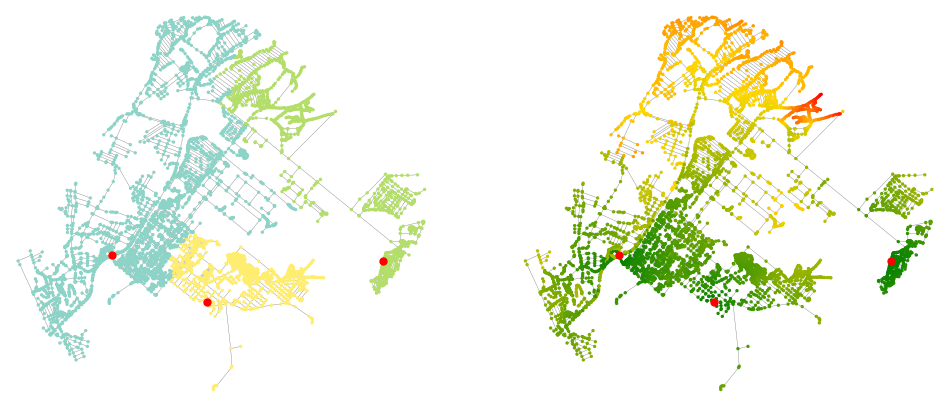

In [40]:
def voronoi_forest(G, sources, path_function, cutoff=None, weight='travel_time', routes_return=False):

    # Расчет
    times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
    times = pd.Series(times, dtype=float)

    # Определение стартового узла для каждого маршрута
    if isinstance(sources, dict):
        nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str)
    else:
        nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64')

    # Построение леса
    # times_forest = {s:{k:v} for s,k,v in zip(nearest, times.items())}

    if routes_return:
        routes = pd.Series(routes)
        return nearest, times, routes
    else:
        return nearest, times


#===========================================================================================
print('0', end='\r')
ndl = list(G.nodes())
# start_points = [ndl[100], ndl[2000], ndl[3000]]
start_points = {ndl[100]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
nearest, times = voronoi_forest(G, start_points, nx.multi_source_dijkstra)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

In [4]:
@staticmethod
def cover_index(
            ip_val=10):
    '''
    Расчет индекса прикрытия.

    Аргументы
    ---------
    `ip_val`:int
        Пороговое значение для определения индекса прикрытия.
        Рекомендуется использовать 10 для городских населенных пунктов и 
        20 для сельских.

    Возвращает
    ----------
    `metric_val`: float
        Значение целевой метрики

    Пример
    ------
    Вызывается как результат выполнения функции с заданными параметрами:

    для расчета ИП-10:
        `calc_ip()` или `calc_ip(ip_val=10)`
    для расчета ИП-20:
        `calc_ip(ip_val=20)`
    '''
    def _cover_index(route_times:pd.Series):
        '''Расчет индекса прикрытия.

        Аргументы
        ---------
        `route_times`:pd.Series
            Серия данных о временах прибытия в узлы ГДС 
            (или вообще произвольных данных о временах прибытия)
        '''
        if not isinstance(route_times, pd.Series):
            raise TypeError(
                "Аргумент route_times может быть только типа pd.Series"
                )

        tot_len = len(route_times)
        if tot_len==0:
            return 0
        ip_len = sum(route_times<=ip_val)
        return 100*ip_len/tot_len

    return _cover_index

# Расчет метрик для всего результата
metrics = {}
metrics['mean_arr_time'] = np.mean(times)
metrics['max_arr_time'] = np.max(times)
metrics['median_arr_time'] = np.median(times)

metrics['ip5'] = cover_index(5)(times)
metrics['ip10'] = cover_index()(times)
metrics['ip20'] = cover_index(20)(times)

print(pd.Series(metrics))

mean_arr_time       6.509977
max_arr_time       22.958373
median_arr_time     5.383067
ip5                46.838663
ip10               75.581395
ip20               99.691134
dtype: float64


In [5]:
# Расчет метрик для каждого из подразделений
for start_point in nearest.unique():
    times_part = pd.Series([t for n,t in zip(nearest, times) if n==start_point], dtype=times.dtype)
    print(start_point)
    metrics = {}
    metrics['mean_arr_time'] = np.mean(times_part)
    metrics['max_arr_time'] = np.max(times_part)
    metrics['median_arr_time'] = np.median(times_part)

    metrics['ip5'] = cover_index(5)(times_part)
    metrics['ip10'] = cover_index()(times_part)
    metrics['ip20'] = cover_index(20)(times_part)

    print(pd.Series(metrics))
    print(' ')

A
mean_arr_time        6.382747
max_arr_time        15.874785
median_arr_time      5.493972
ip5                 45.509893
ip10                77.960426
ip20               100.000000
dtype: float64
 
B
mean_arr_time       8.787579
max_arr_time       22.958373
median_arr_time    10.331133
ip5                29.421353
ip10               49.470253
ip20               98.614507
dtype: float64
 
C
mean_arr_time        4.114145
max_arr_time         7.456096
median_arr_time      3.963406
ip5                 72.782258
ip10               100.000000
ip20               100.000000
dtype: float64
 


In [88]:
def nodes_metric(G, sources, path_function, metric_function, voronoi_function, cutoff=None, weight='travel_time', **kwargs):
    _, times = voronoi_function(G=G, sources=sources, path_function=path_function, cutoff=cutoff, weight=weight, **kwargs)
    return metric_function(times)


start_points = {ndl[100]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
# start_points = [ndl[100]]
nodes_metric(G, start_points, nx.multi_source_dijkstra, metric_function=np.mean, voronoi_function=voronoi_forest)

6.509977493498235

In [60]:
poly = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

In [57]:
def voronoi_forest_for_points(points, **kwargs):
    results = voronoi_forest(**kwargs)
    
    r_out=[]
    for r in results:
        val = dict(filter( lambda x: x[0] in points, r.items()))
        r_out.append(pd.Series(val))
    return r_out

In [82]:
def voronoi_forest_for_area(area, **kwargs):
    # print(kwargs['G'].graph.get('crs'))

    if not area.crs == G.graph.get('crs'):
        raise ValueError(f'Системы координат полигона `area` ({area.crs}) и `графа` G ({G.graph.get("crs")}) не совпадают!')

    nodes = ox.graph_to_gdfs(kwargs['G'], edges=False)
    points = nodes[nodes.within(area.iloc[0].geometry)]
    points = list(points.index)
    # print(points)

    return voronoi_forest_for_points(points=points, **kwargs)


# ======== Проверка ========================
nearest, times = voronoi_forest_for_area(G=G, 
                                        sources=start_points,
                                        path_function=nx.multi_source_dijkstra,
                                        area=poly)
nearest

2760591335    C
2760591341    C
5574240371    C
5703333240    C
1644098164    A
             ..
4116035750    A
4116035751    A
4116035752    A
4116035977    A
4116035978    A
Length: 2237, dtype: object

In [62]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes

,y,x,street_count,highway,geometry
osmid,,,,,
290700344,56.162667,93.360388,2,NaN,POINT (93.36039 56.16267)
290700348,56.162327,93.359660,2,NaN,POINT (93.35966 56.16233)
290700352,56.161600,93.358188,2,NaN,POINT (93.35819 56.16160)
290700353,56.161100,93.356967,2,NaN,POINT (93.35697 56.16110)
290700355,56.159615,93.352813,2,NaN,POINT (93.35281 56.15962)
...,...,...,...,...,...
10861562817,56.123782,93.301762,4,NaN,POINT (93.30176 56.12378)
10861562818,56.123778,93.302198,4,NaN,POINT (93.30220 56.12378)
10861562819,56.123544,93.304071,3,NaN,POINT (93.30407 56.12354)


In [65]:
nearest.name = 'nearest'
nodes = nodes.join(nearest)

ax = nodes[nodes['nearest'].notna()].plot(markersize=1)
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
poly.boundary.plot(ax=ax, color='r')

In [84]:
def nodes_metric(G, sources, path_function, metric_function, voronoi_function, cutoff=None, weight='travel_time', **kwargs):
    _, times = voronoi_function(G=G, sources=sources, path_function=path_function, cutoff=cutoff, weight=weight, **kwargs)
    return metric_function(times)

nodes_metric(G, start_points, nx.multi_source_dijkstra,
             metric_function=np.mean,
             voronoi_function=voronoi_forest_for_area,
             area=poly)

4.2880732710581775

In [85]:
nodes_metric(G, start_points, nx.multi_source_dijkstra,
             metric_function=np.mean,
             voronoi_function=voronoi_forest)

6.509977493498235

# Тест готовых функций

In [2]:
from genesis.optimal_service_areas import voronoi_forest, voronoi_forest_for_area, voronoi_forest_for_points, voronoi_forest_for_points_mask, voronoi_forest_for_points_mask2
from genesis.swiss_knife import MSF
from genesis.estimated_arrival_parameters import *

In [3]:
area = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

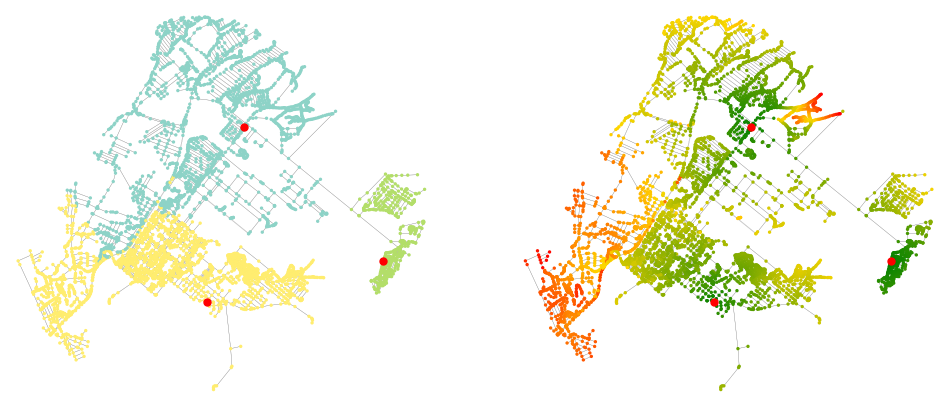

In [5]:
print('0', end='\r')
ndl = list(G.nodes())
# start_points = [ndl[1000], ndl[2000], ndl[3000]]
start_points = {ndl[1000]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
nearest, times = voronoi_forest(G, start_points, nx.multi_source_dijkstra)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

<Axes: >

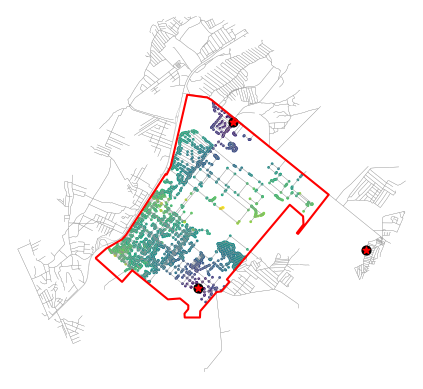

In [7]:
# Расчет параметров прибытия
nearest, times = voronoi_forest_for_area(G=G, 
                                         sources=start_points, 
                                         path_function=MSF,
                                         area=area)

# Получение итогового геодатафрейма
nodes = ox.graph_to_gdfs(G, edges=False)
nodes = pd.concat([nodes, nearest, times], axis=1)
# # nearest.name = 'first_arrival_unit'
# nodes = nodes.join(nearest)
# # times.name = 'route_times'
# nodes = nodes.join(times)



# Печать карты
ax = nodes[nodes['first_arrival_unit'].notna()].plot(markersize=1, column='route_time')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
area.boundary.plot(ax=ax, color='r')
nodes.loc[locations.keys()].plot(ax=ax, markersize=40, color='k')
nodes.loc[locations.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

In [22]:
nodes_metric(G, start_points, nx.multi_source_dijkstra,
             metric_function=np.mean,
             voronoi_function=voronoi_forest_for_area,
             area=area)

4.3642432706111505

## Работа по разработке алгоритмов расчет лучшего узла

In [4]:
from genesis.tools import Progressbar

In [5]:
def best_node_full(G,
                   path_function=MSF,
                   metric_function=np.mean,
                   voronoi_function=voronoi_forest,
                   nodes_list=None,
                   node_calc_end_function=None,
                   **kwargs):
   if nodes_list is None:
        nodes_list = G.nodes()
   
   best_metric = None
   best_node = None
   for node in nodes_list:
      node_metric = nodes_metric(G=G,
            sources=[node],
            path_function=path_function,
            metric_function=metric_function,
            voronoi_function=voronoi_function,
            **kwargs)
      # здесь должна быть проверка на корректность охвата графа
      if best_metric is None:
         best_metric = node_metric
         best_node = node
      if best_metric > node_metric:
         best_metric = node_metric
         best_node = node
      if node_calc_end_function:
         node_calc_end_function()
      
   return best_node, best_metric

# =================== Проверка ============================
nodes_list = list(G.nodes())[:500]
pb = Progressbar(len(nodes_list), bins=40)

best_node, best_metric = best_node_full(G=G,
               nodes_list=nodes_list,
               node_calc_end_function=pb)

best_node, best_metric

|#######################################_| 99.8%


(426923808, 7.355415617070702)

<Axes: >

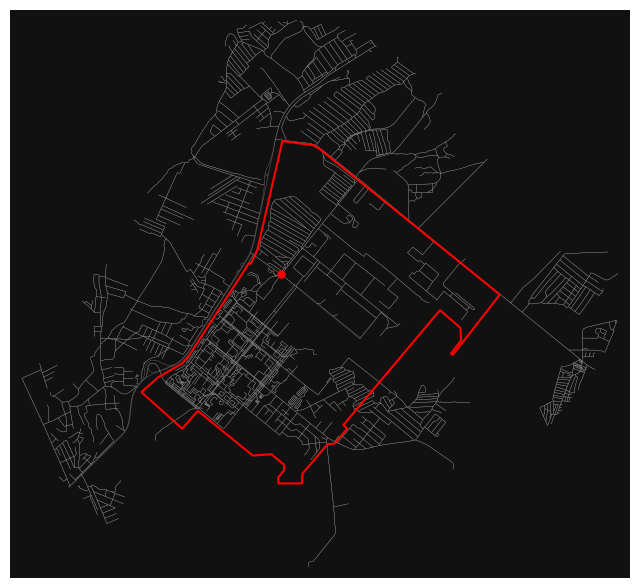

In [25]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[[best_node]].plot(ax=ax, markersize=25, color='red')

In [84]:
# def voronoi_forest(G, sources, path_function, cutoff=None, weight='travel_time', routes_return=False):
#     '''
#     Расчет Леса Вороного.
#     Алгоритм расчета времен прибытия первого подразделения в узлы графа.

#     # Аргументы
#     `G`: nx.MultiDiGraph
#         Граф улично-дорожной сети.
#     `sources`:list|dict
#         Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
#         идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
#         расположены пожарные подразделения: {1234:'ПСЧ-1'}
#     `path_function`: function
#         Функция расчета кратчайших путей от единственного источника. 
#         В качестве функции могут быть переданы реализации алгоритмов из пакета
#         `networkx`. Например, реализация алгоритма Дейкстры: `nx.multi_source_dijkstra`.
#         Пользователь может использовать собственные функции с
#         интерфейсом `func(G: Graph, sources: Any, target: Any | None = None, cutoff: Any | None = None, 
#         weight: str = "weight") -> (dict, dict)`
#     `cutoff`:int=None
#         Ограничение расчета
#     `weight`:str или function  = "travel_time"
#         Имя поля содержащего вес ребер, или функция позволяющая вычислять 
#         вес динамически.
#     `routes_return`: bool = False
#         Возвращать ли также и маршруты следования
#     '''

#     if not isinstance(sources, (list, dict)):
#         raise TypeError(f'Тип данных аргумента `sources` должен быть (list или dict)')

#     # Расчет
#     times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
#     times = pd.Series(times, dtype=float, name='route_time')

#     # Определение стартового узла для каждого маршрута
#     if isinstance(sources, dict):
#         nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str, name='first_arrival_unit')
#     else:
#         nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64', name='first_arrival_unit')

#     # Построение леса
#     # times_forest = {s:{k:v} for s,k,v in zip(nearest, times.items())}

#     if routes_return:
#         routes = pd.Series(routes)
#         return nearest, times, routes
#     else:
#         return nearest, times


# def voronoi_forest_for_points(points, **kwargs):
#     '''
#     Расчет леса Вороного и возвращение значений для узлов points

#     # Аргументы
#     `points`: list(int)
#         Список точек значения для которых должны быть возвращены.
#     `**kwargs`:
#         Аргументы функции `voronoi_forest`

#     # Возвращает
#         [nearest, times], [nearest, times, routes]:
#         `nearest`:dict - словарь значений ближайших к текущему узлу стартовых узлов
#         `times`:dict - словарь значений времени следования в каждый из узлов
#         `routes`:dict - словарь маршрутов следования в каждый из узлов
#     '''
#     print('Функция `voronoi_forest_for_points` устарела и будет в последующем заменена, не рекомендуется ее использование')
#     if not isinstance(points, list):
#         raise TypeError(f'Аргумент `points` должен иметь тип `list`! Имеет {type(points)}')

#     results = voronoi_forest(**kwargs)

#     r_out=[]
#     for r in results:
#         val = dict(filter( lambda x: x[0] in points, r.items()) )
#         r_out.append(pd.Series(val))
#     return r_out


# def voronoi_forest_for_area(area:gpd.GeoDataFrame, **kwargs):
#     '''
#     Расчет леса Вороного и возвращение значений для набора геоданных area

#     # Аргументы
#     `area`:gpd.GeoDataFrame
#         Геодатафрейм содержащий полигоны границ области. 
        
#         Важно! Геодатафрейм должен содержать строго 1 запись!
#     `**kwargs`:
#         Аргументы функции `voronoi_forest`

#     # Возвращает
#         [nearest, times], [nearest, times, routes]:
#         `nearest`:dict - словарь значений ближайших к текущему узлу стартовых узлов
#         `times`:dict - словарь значений времени следования в каждый из узлов
#         `routes`:dict - словарь маршрутов следования в каждый из узлов
#     '''

#     if not len(area)==1:
#         raise ValueError(f'В наборе геоданных `area` должно содержаться строго 1 запись! Содержится {len(area)}!')

#     try:
#         G = kwargs['G']
#     except Exception as exc:
#         raise TypeError(
#             exc
#             ) from exc

#     if not area.crs == G.graph.get('crs'):
#         raise ValueError(f'Системы координат полигона `area` ({area.crs}) и `графа` G ({G.graph.get("crs")}) не совпадают!')

#     nodes = ox.graph_to_gdfs(G, edges=False)
#     points_mask = nodes.within(area.iloc[0].geometry)

#     return voronoi_forest_for_points_mask(points_mask=points_mask, **kwargs)


# def voronoi_forest_for_points_mask(points_mask, to_df=False, **kwargs):
#     '''
#     Расчет леса Вороного и возвращение значений для маски узлов points

#     # Аргументы
#     `points_mask`: list(int)
#         Маска точек значения для которых должны быть возвращены.
#     `to_df`: bool
#         Если True, то при проведении расчета, данные промежуточно преобразовываются к 
#         pd.DataFrame. Скорость расчета несколько увеличивается, но результат остается тем же!
#     `**kwargs`:
#         Аргументы функции `voronoi_forest`

#     # Возвращает
#         [nearest, times], [nearest, times, routes]:
#         `nearest`:dict - словарь значений ближайших к текущему узлу стартовых узлов
#         `times`:dict - словарь значений времени следования в каждый из узлов
#         `routes`:dict - словарь маршрутов следования в каждый из узлов
#     '''
#     # if not isinstance(points_mask, list):
#     #     raise TypeError(f'Аргумент `points_mask` должен иметь тип `list`! Имеет {type(points_mask)}')

#     results = voronoi_forest(**kwargs)

#     if to_df:
#         result_names = [r.name for r in results]
#         r_out = pd.concat([r.to_frame() for r in results], axis=1).loc[points_mask]
#         return [r_out[n] for n in result_names]
#     else:
#         r_out=[]
#         for r in results:
#             val = r[points_mask]
#             r_out.append(pd.Series(val))
#         return r_out

# def voronoi_forest_for_points_mask2(points_mask, **kwargs):
#     return voronoi_forest_for_points_mask(points_mask=points_mask, to_df=True, **kwargs)


In [6]:
#===============================================================================================
print('Тест времени расчета лучшего узла с использованием разных функций леса Вороного:')
cnt = 1000
nodes_list = list(G.nodes())[:cnt]
print('Узлов:', cnt)
print('='*80)


nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)
points = nodes[points_mask]
points = list(points.index)


st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest', round(ft-st,2))
print(best_node, best_metric)

st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest_for_points,
               points=points,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_points', round(ft-st,2))
print(best_node, best_metric)

st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest_for_area,
               area=area,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_area', round(ft-st,2))
print(best_node, best_metric)

st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest_for_points_mask,
               points_mask=points_mask,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_points_mask', round(ft-st,2))
print(best_node, best_metric)

st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest_for_points_mask2,
               points_mask=points_mask,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_points_mask2', round(ft-st,2))
print(best_node, best_metric)
print(' ')

best_node, best_metric

Тест времени расчета лучшего узла с использованием разных функций леса Вороного:
Узлов: 1000
|#######################################_| 99.9%

best_node_full + voronoi_forest 56.97
426923808 7.355415617070702
|#######################################_| 99.9%

best_node_full + voronoi_forest_for_points 464.51
1577701962 3.3284016447729736
|#######################################_| 99.9%

best_node_full + voronoi_forest_for_area 335.71
1577701962 3.3284016447729736
|#######################################_| 99.9%

best_node_full + voronoi_forest_for_points_mask 65.21
1577701962 3.3284016447729736
|#######################################_| 99.9%

best_node_full + voronoi_forest_for_points_mask2 67.55
1577701962 3.3284016447729736


(1577701962, 3.3284016447729736)

Вывод: Наиболее быстрой реализацией функции расчета леса Вороного с ограничением по полигону является voronoi_forest_for_points_mask

<Axes: >

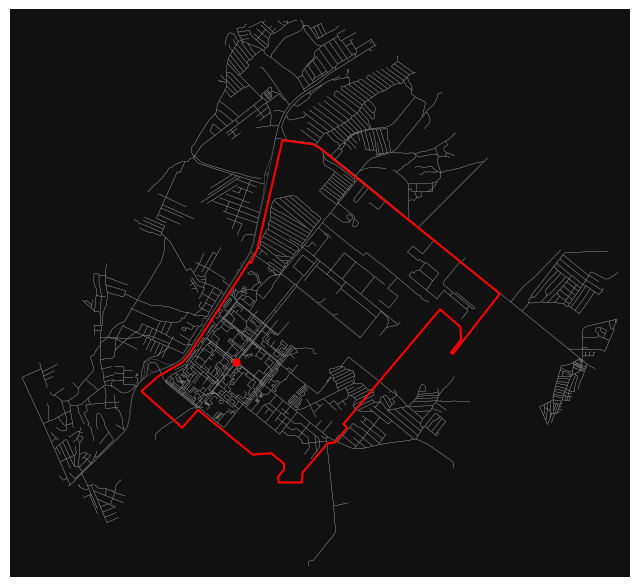

In [94]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[[best_node]].plot(ax=ax, markersize=25, color='red')

# Тестирование логирования

In [1]:
import logging

In [2]:
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity


In [4]:
logging.basicConfig(level=logging.INFO, filename="py_log.log",filemode="w")
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity
